### Step 1: Import COEUR

In [9]:
from coeur.score import Coeur
from coeur.cohesion import CohesionScore
from coeur.exhaustiveness import ExhaustivenessScore
from sklearn.cluster import SpectralClustering

### Step 2: Initialize COEUR Scorer Object

In [2]:
coeur_scorer = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
                     remove_re_se_stopwords=True)
R, B = coeur_scorer.load_data(ref_path="datasets/trident/trident_specs.pdf",
                cand_path="datasets/trident/trident_backlog.csv")

### Step 3: Compute Score

Where $l=$"s" indicates that the Exhaustiveness is computed on story level, $l=$"e" on epic level and $l=$"b" on backlog level.
$\mathcal{R}$ is the reference specifications and $\mathcal{B}$ the candidate backlog. $\lambda=0.5$ is the weight given to the Exhaustiveness in the final COEUR score. $\sigma=$"auto" is ROUGE-2 Precision and $\psi=$"auto" is the Adjusted Mutual Information.

In [3]:
coeur_scorer.score(R, B, l="s", lmbd=0.5,
                   sigma="auto", psi="auto", phi="auto")

{'COEUR': 0.2964029539389451,
 'Cohesion': 0.392479955538661,
 'Exhaustiveness': 0.20032595233922929}

In [4]:
coeur_scorer.score(R, B, l="e", lmbd=0.5,
                   sigma="auto", psi="auto", phi="auto")

{'COEUR': 0.2802264207416829,
 'Cohesion': 0.392479955538661,
 'Exhaustiveness': 0.1679728859447048}

In [5]:
coeur_scorer.score(R, B, l="b", lmbd=0.5,
                   sigma="auto", psi="auto", phi="auto")

{'COEUR': 0.24063250113381648,
 'Cohesion': 0.392479955538661,
 'Exhaustiveness': 0.08878504672897196}

### Step 4: Explain Score Details

Reports can be generated by setting `plot=True` with the `explain` method. This allows to understand user stories invidual contributions of Cohesion and Exhaustiveness to the final Coeur score. Additionally, the main dashboard and sub-reports for Cohesion and Exhaustiveness can be used by human experts to identify strengths and weaknesses of the user story and efficiently improve them.

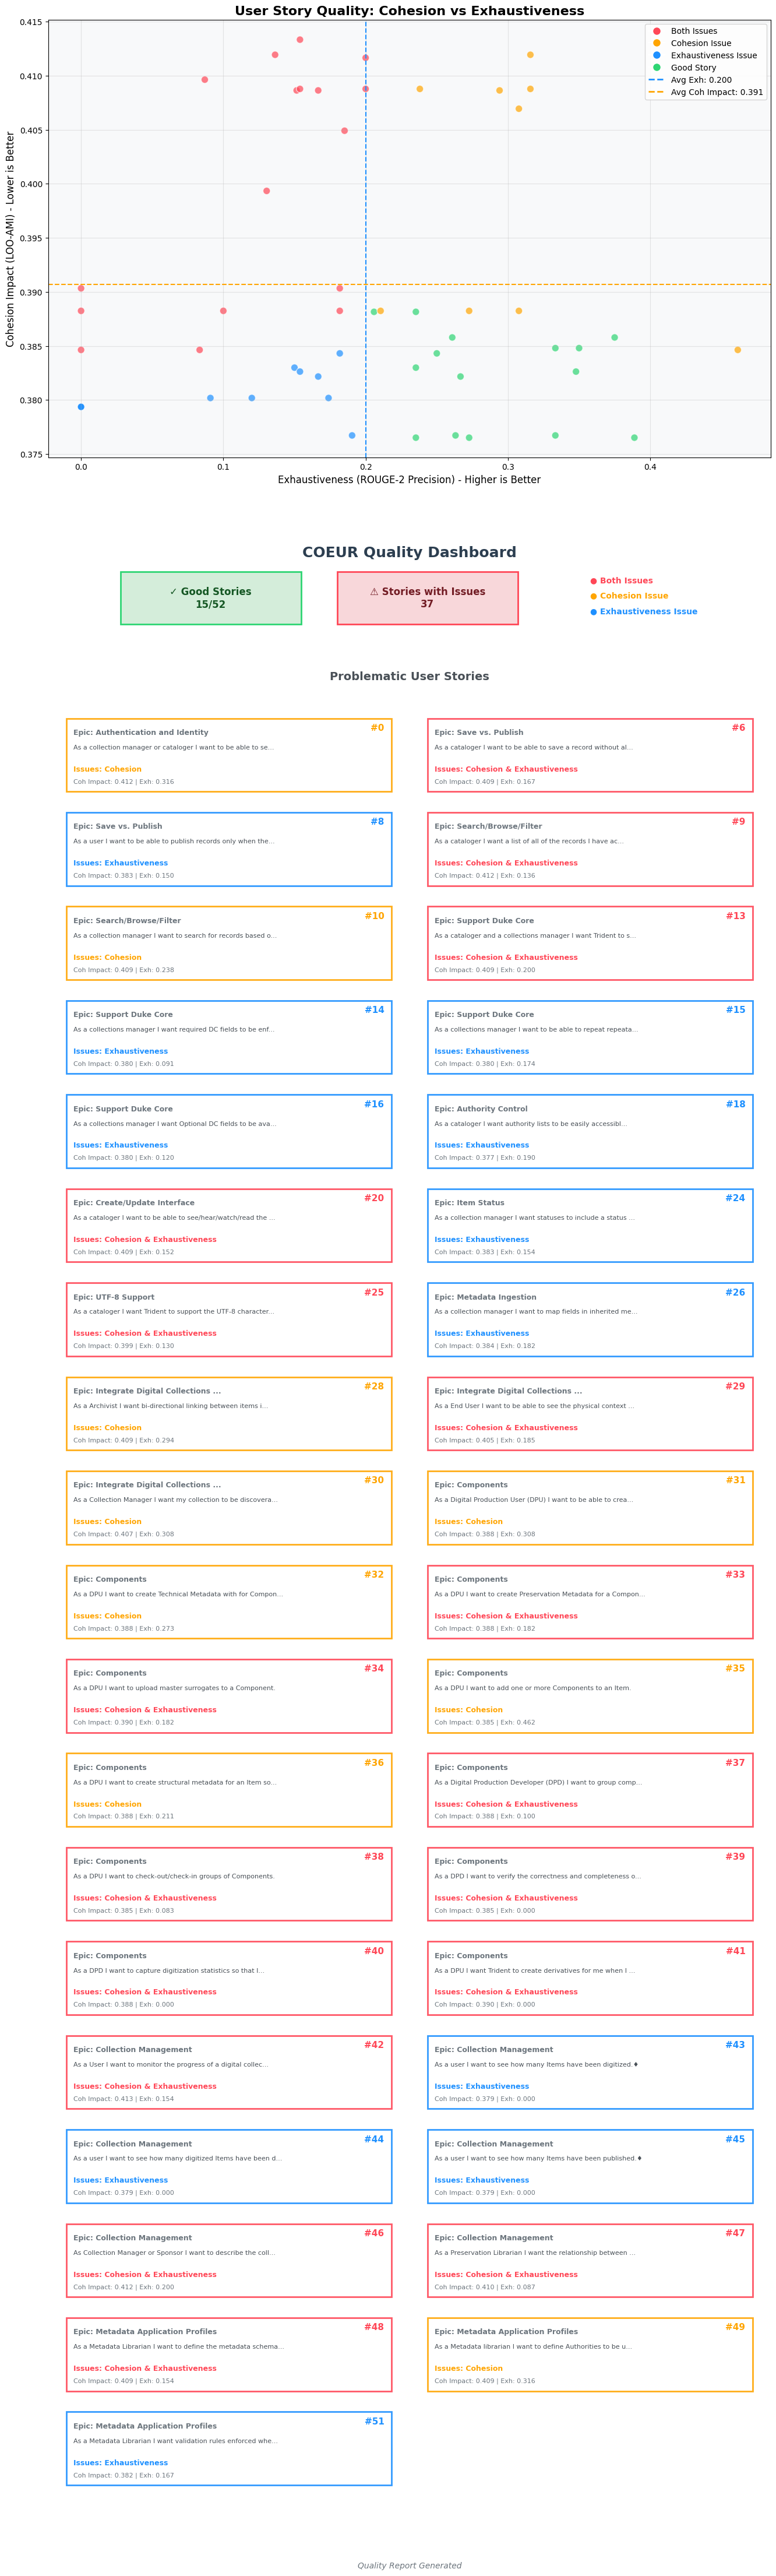

In [7]:
_ = coeur_scorer.explain(R, B, l="s", plot=True)

You can also generate sub-reports for Cohesion and Exhaustiveness separately.

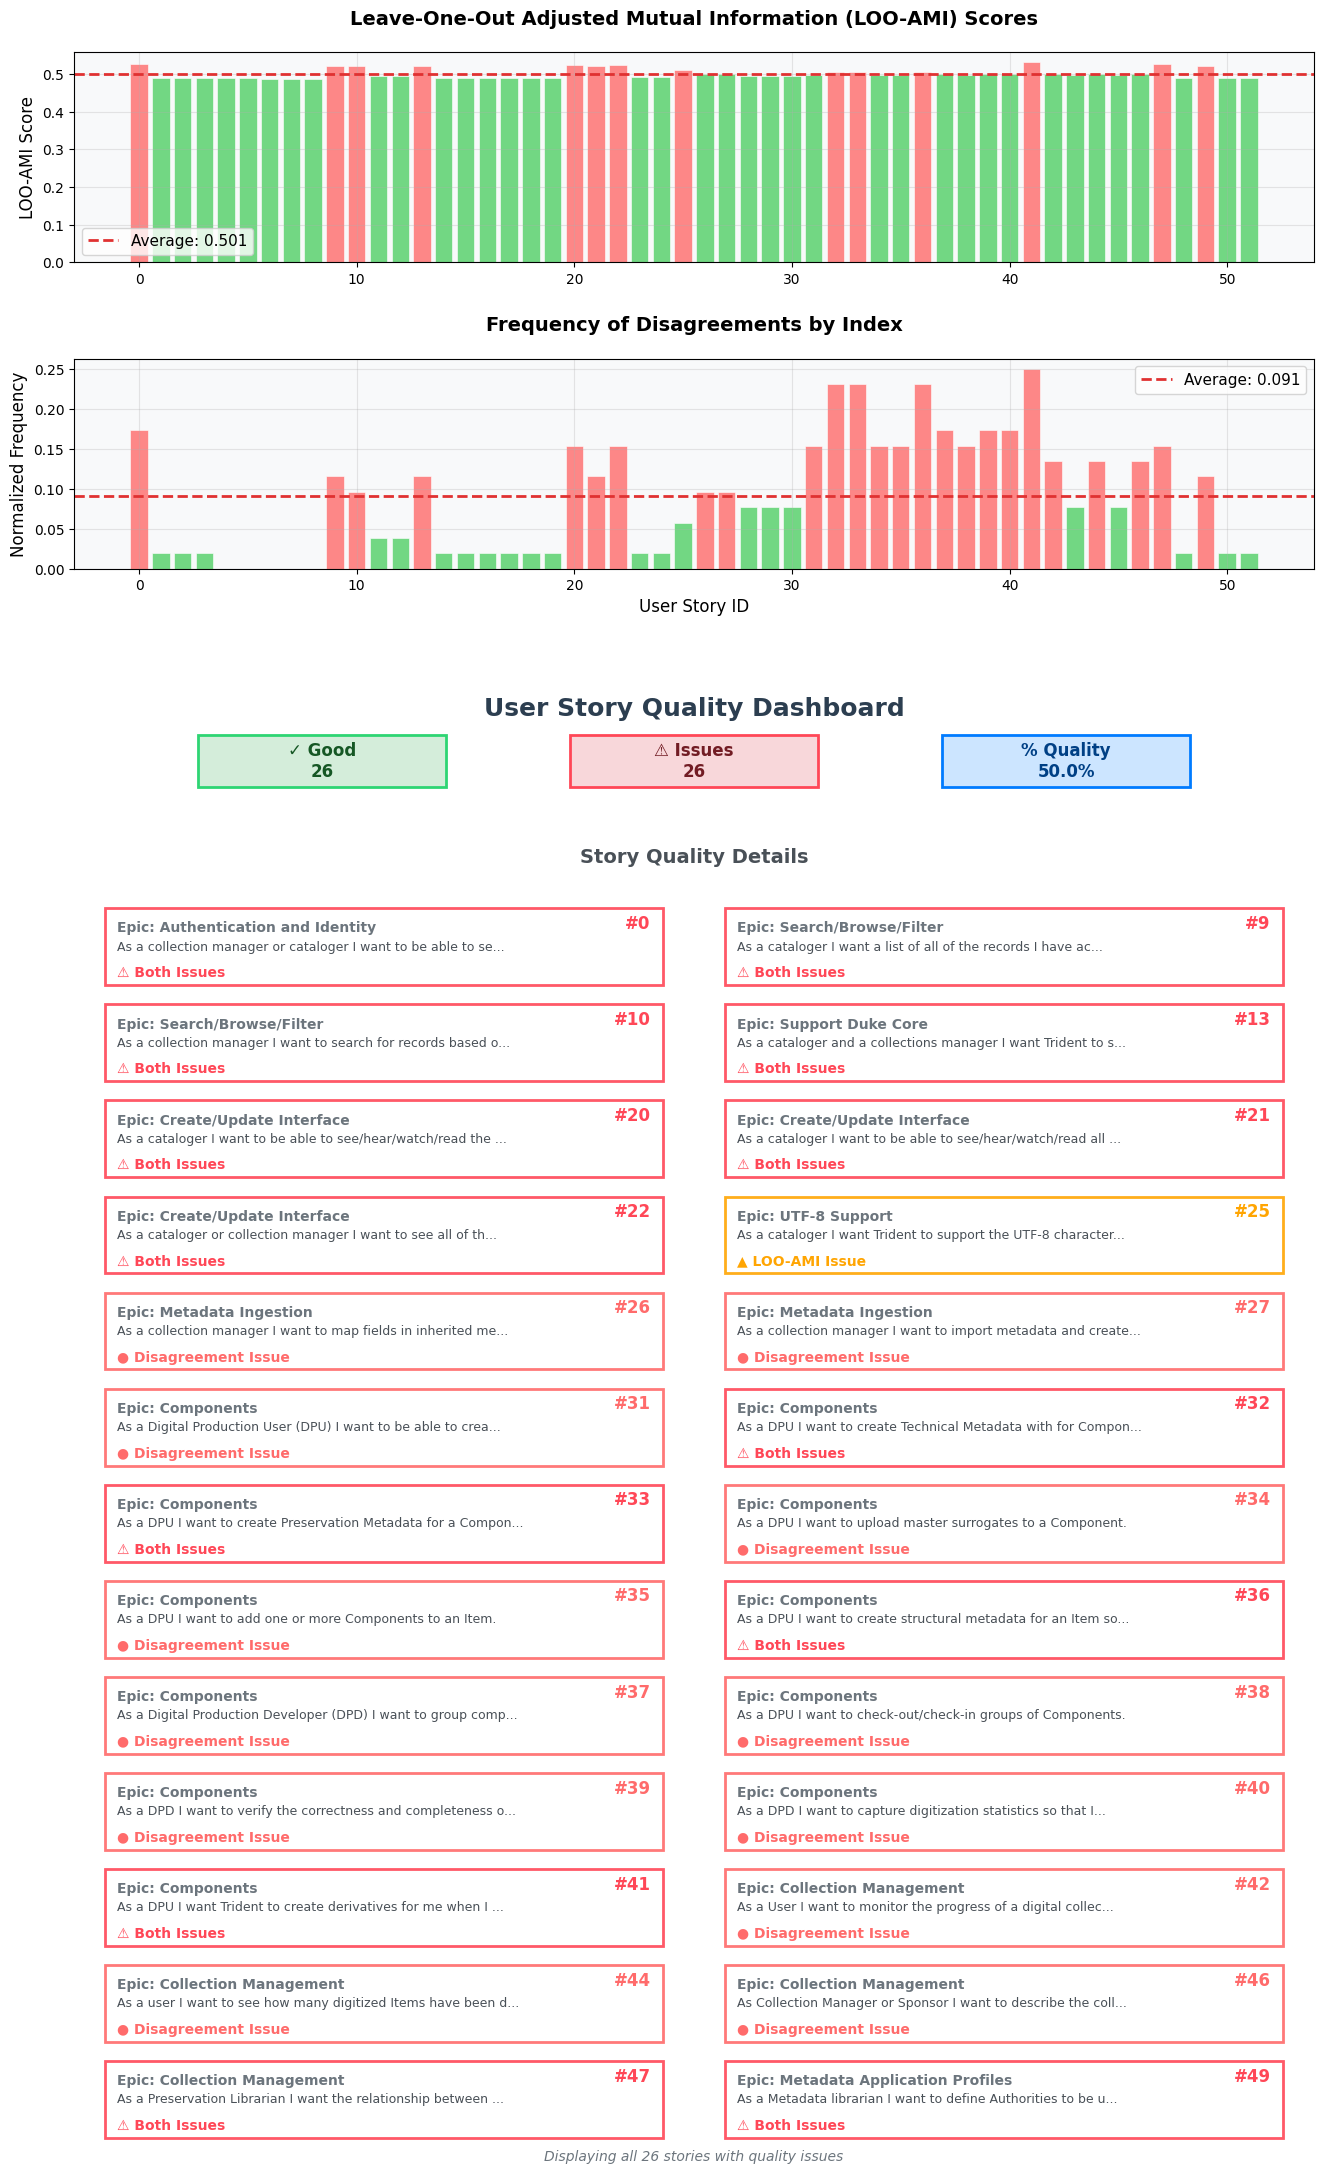

In [17]:
n_epics = len(B["epic"].unique())
coh_scorer = CohesionScore(clusterer=SpectralClustering(n_clusters=n_epics))
_ = coh_scorer.explain(B, plot=True)